# Primetrade.ai AI Internship Task

## Trader Performance vs Bitcoin Market Sentiment

This notebook analyzes Hyperliquid historical trader data alongside the Bitcoin Fear & Greed Index. The focus is not only EDA, but also a usable trader strategy layer: sentiment-aware PnL, win-rate, profit factor, capital efficiency, trader specialization, and a predictive sanity check.

## Method summary

- Parse Hyperliquid timestamps in IST.
- Join each trade/fill row with daily sentiment by date.
- Forward-fill the one missing sentiment date in the trading range.
- Separate activity rows from realized PnL rows (`Closed PnL != 0`).
- Compute `net_pnl = Closed PnL - Fee`.
- Score sentiment regimes using net PnL, win-rate, profit factor, and PnL per $1k notional.
- Add statistical tests and an out-of-time predictive check.

In [1]:

import warnings, math
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_HIST = Path('historical_data.csv')
RAW_SENT = Path('fear_greed_index.csv')
# For this generated version, fallback to /mnt/data paths if run inside the ChatGPT sandbox.
if not RAW_HIST.exists(): RAW_HIST = Path('/mnt/data/historical_data.csv')
if not RAW_SENT.exists(): RAW_SENT = Path('/mnt/data/fear_greed_index.csv')

OUT = Path('primetrade_outputs')
CHARTS = OUT / 'charts'
TABLES = OUT / 'tables'
for p in [OUT, CHARTS, TABLES]: p.mkdir(parents=True, exist_ok=True)

sent_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

hist = pd.read_csv(RAW_HIST)
fgi = pd.read_csv(RAW_SENT)

hist['dt'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
hist['date'] = hist['dt'].dt.normalize()
fgi['date'] = pd.to_datetime(fgi['date'], errors='coerce')
fgi = fgi.dropna(subset=['date']).sort_values('date')

full_dates = pd.DataFrame({'date': pd.date_range(hist['date'].min(), hist['date'].max(), freq='D')})
fgi_full = full_dates.merge(fgi[['date','value','classification']], on='date', how='left')
fgi_full['sentiment_imputed'] = fgi_full['classification'].isna()
fgi_full['value'] = fgi_full['value'].ffill().bfill()
fgi_full['classification'] = fgi_full['classification'].ffill().bfill()
fgi_full['prev_value'] = fgi_full['value'].shift(1)
fgi_full['prev_classification'] = fgi_full['classification'].shift(1)
fgi_full['sentiment_delta'] = (fgi_full['value'] - fgi_full['prev_value']).fillna(0)

m = hist.merge(fgi_full, on='date', how='left')
m['gross_pnl'] = m['Closed PnL']
m['net_pnl'] = m['Closed PnL'] - m['Fee']
m['is_realized'] = m['Closed PnL'].ne(0)
m['is_win'] = m['net_pnl'].gt(0)
m['notional_usd'] = m['Size USD']
m['hour'] = m['dt'].dt.hour
m['weekday'] = m['dt'].dt.day_name()
m['month'] = m['dt'].dt.to_period('M').astype(str)
m['direction_group'] = np.select(
    [m['Direction'].str.contains('Long', case=False, na=False),
     m['Direction'].str.contains('Short', case=False, na=False),
     m['Direction'].isin(['Buy','Sell'])],
    ['Long','Short','Spot/Swap'], default='Other')
m['size_bucket'] = pd.cut(m['Size USD'], bins=[0,100,1000,10000,100000,np.inf], labels=['<$100','$100-$1k','$1k-$10k','$10k-$100k','>$100k'], include_lowest=True)

def score(df):
    rows = len(df)
    r = df[df['is_realized']]
    wins = r.loc[r['net_pnl'] > 0, 'net_pnl']
    losses = r.loc[r['net_pnl'] < 0, 'net_pnl']
    net = df['net_pnl'].sum(); gross = df['gross_pnl'].sum(); fees = df['Fee'].sum(); notional = df['notional_usd'].sum()
    loss_abs = abs(losses.sum())
    return pd.Series({
        'rows': rows,
        'realized_trades': len(r),
        'realized_rate': len(r)/rows if rows else np.nan,
        'notional_usd': notional,
        'gross_pnl': gross,
        'fees': fees,
        'net_pnl': net,
        'avg_net_per_row': net/rows if rows else np.nan,
        'avg_net_per_realized': r['net_pnl'].mean() if len(r) else np.nan,
        'median_net_realized': r['net_pnl'].median() if len(r) else np.nan,
        'win_rate_realized': (r['net_pnl'] > 0).mean() if len(r) else np.nan,
        'profit_factor': wins.sum()/loss_abs if loss_abs else np.inf,
        'pnl_per_1k_notional': net/notional*1000 if notional else np.nan,
        'avg_fee_bps': fees/notional*10000 if notional else np.nan,
    })

print('Rows:', len(m))
print('Realized rows:', int(m['is_realized'].sum()))
print('Accounts:', m['Account'].nunique(), 'Coins:', m['Coin'].nunique())
print('Range:', m['dt'].min(), 'to', m['dt'].max())
print('Imputed sentiment dates:', int(fgi_full['sentiment_imputed'].sum()))
score(m).to_frame('value')


Rows: 211224
Realized rows: 104408
Accounts: 32 Coins: 246
Range: 2023-05-01 01:06:00 to 2025-05-01 12:13:00
Imputed sentiment dates: 1


,value
rows,2.112240e+05
realized_trades,1.044080e+05
realized_rate,4.942999e-01
notional_usd,1.191187e+09
gross_pnl,1.029696e+07
fees,2.458577e+05
net_pnl,1.005110e+07
avg_net_per_row,4.758503e+01
avg_net_per_realized,9.742658e+01
median_net_realized,5.777634e+00


## Sentiment scorecard

This table is the core assignment output. It shows how profitability, realized win-rate, profit factor, and capital efficiency change across market sentiment regimes.

In [2]:

sentiment_score = m.groupby('classification').apply(score).reindex(sent_order)
sentiment_score[['rows','realized_trades','notional_usd','net_pnl','avg_net_per_realized','median_net_realized','win_rate_realized','profit_factor','pnl_per_1k_notional']]


,rows,realized_trades,notional_usd,net_pnl,avg_net_per_realized,median_net_realized,win_rate_realized,profit_factor,pnl_per_1k_notional
classification,,,,,,,,,
Extreme Fear,21400.0,10406.0,1.144843e+08,7.152216e+05,69.852009,6.127954,0.757736,2.138120,6.247336
Fear,61837.0,29808.0,4.833248e+08,3.264698e+06,111.049256,6.010164,0.853697,6.503309,6.754668
Neutral,37686.0,18159.0,1.802421e+08,1.253546e+06,69.974007,4.389699,0.820199,4.236304,6.954794
Greed,50309.0,25182.0,2.886712e+08,2.129494e+06,85.891314,4.638648,0.761735,3.030543,7.376885
Extreme Greed,39992.0,20853.0,1.244652e+08,2.688141e+06,129.549966,8.391439,0.887882,10.898560,21.597534


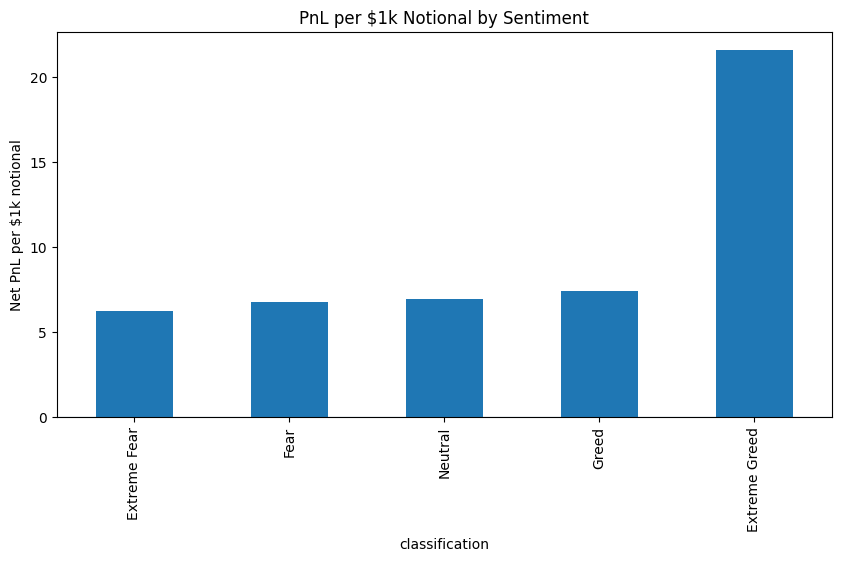

In [3]:

ax = sentiment_score['pnl_per_1k_notional'].plot(kind='bar', figsize=(10,5), title='PnL per $1k Notional by Sentiment')
ax.set_ylabel('Net PnL per $1k notional')
ax.axhline(0, linewidth=0.8)
plt.show()


## Directional behavior by sentiment

This section checks whether long, short, and spot/swap-like activity behaves differently across regimes.

In [4]:

direction_sentiment = m.groupby(['classification','direction_group']).apply(score).reset_index()
direction_sentiment[['classification','direction_group','rows','realized_trades','net_pnl','win_rate_realized','profit_factor','pnl_per_1k_notional']].sort_values(['classification','direction_group'])


,classification,direction_group,rows,realized_trades,net_pnl,win_rate_realized,profit_factor,pnl_per_1k_notional
0,Extreme Fear,Long,13257.0,6252.0,4.773830e+05,0.844530,3.318953,5.583854
1,Extreme Fear,Other,3.0,0.0,0.000000e+00,NaN,inf,0.000000
2,Extreme Fear,Short,6291.0,3117.0,3.791130e+05,0.696503,2.410091,14.400700
3,Extreme Fear,Spot/Swap,1849.0,1037.0,-1.412744e+05,0.418515,0.108292,-53.015301
4,Extreme Greed,Long,13504.0,7203.0,4.307372e+05,0.882271,17.566342,7.460700
5,Extreme Greed,Other,32.0,0.0,0.000000e+00,NaN,inf,0.000000
6,Extreme Greed,Short,14160.0,6489.0,1.781698e+05,0.853444,1.844391,3.943651
7,Extreme Greed,Spot/Swap,12296.0,7161.0,2.079234e+06,0.924731,72.135831,96.474669
8,Fear,Long,35116.0,17292.0,1.394355e+06,0.883009,4.833383,4.278488
9,Fear,Other,42.0,0.0,0.000000e+00,NaN,inf,0.000000


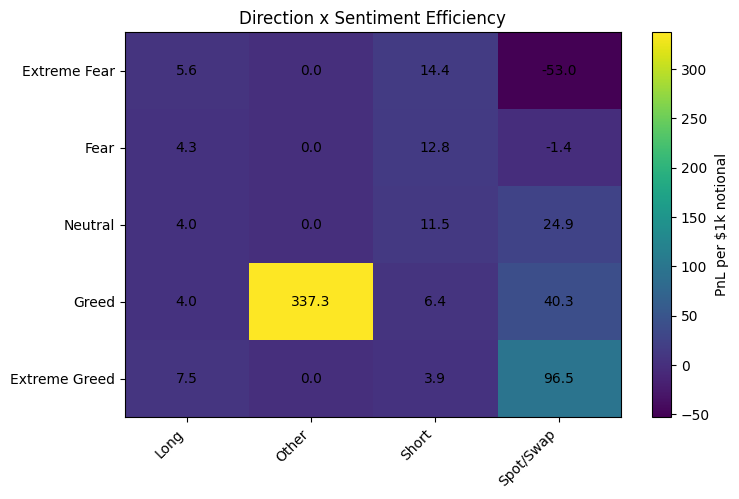

In [5]:

pivot = direction_sentiment.pivot(index='classification', columns='direction_group', values='pnl_per_1k_notional').reindex(sent_order)
fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(pivot.fillna(0).values, aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i,j]
        if pd.notna(val): ax.text(j,i,f'{val:.1f}', ha='center', va='center')
fig.colorbar(im, ax=ax, label='PnL per $1k notional')
ax.set_title('Direction x Sentiment Efficiency')
plt.show()


## Trader specialization matrix

A stand-out addition: identify which trader accounts perform best/worst inside each sentiment regime. This can become a sentiment-aware capital allocation layer.

In [6]:

account_score = m.groupby('Account').apply(score).reset_index().query('realized_trades >= 50').sort_values('net_pnl', ascending=False)
account_sentiment = m.groupby(['Account','classification']).apply(score).reset_index().query('realized_trades >= 50').sort_values('net_pnl', ascending=False)
account_sentiment[['Account','classification','realized_trades','net_pnl','win_rate_realized','profit_factor','avg_net_per_realized','pnl_per_1k_notional']].head(15)


,Account,classification,realized_trades,net_pnl,win_rate_realized,profit_factor,avg_net_per_realized,pnl_per_1k_notional
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1051.0,1.110128e+06,0.890580,1.488139e+01,1057.886654,36.683351
135,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,893.0,1.103779e+06,0.937290,1.393468e+02,1236.946396,213.847322
143,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,6283.0,6.152305e+05,0.955276,1.059903e+04,98.288251,15.103252
137,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,2464.0,5.259622e+05,0.599026,1.894362e+01,215.109958,14.495310
152,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Extreme Greed,4520.0,4.771373e+05,0.885398,1.836520e+01,105.637825,28.868630
78,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,Greed,269.0,4.530280e+05,0.698885,7.456220e+01,1684.799918,89.714911
138,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Neutral,1535.0,3.982666e+05,0.850814,3.126016e+01,260.487605,43.938673
69,0x513b8629fe877bb581bf244e326a047b249c4ff1,Neutral,1443.0,3.679198e+05,0.966736,1.273091e+01,258.243747,5.276647
67,0x513b8629fe877bb581bf244e326a047b249c4ff1,Fear,2576.0,3.295710e+05,0.835404,7.792353e+00,135.025117,1.464194
57,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,Fear,599.0,2.931746e+05,0.953255,3.125140e+02,492.735114,16.083919


## Statistical validation

Statistical tests are included to avoid treating visual patterns as proof. P-values are interpreted cautiously because trade-level PnL is heavy-tailed and fill rows are not perfectly independent.

In [7]:

import scipy.stats as stats
realized_groups = [m[(m['classification']==c)&(m['is_realized'])]['net_pnl'].values for c in sent_order]
kr = stats.kruskal(*realized_groups)
win_table = pd.crosstab(m[m['is_realized']]['classification'], m[m['is_realized']]['is_win']).reindex(sent_order)
chi = stats.chi2_contingency(win_table.fillna(0))
daily = m.groupby('date').agg(net_pnl=('net_pnl','sum'), value=('value','first'), rows=('Account','size'), notional_usd=('notional_usd','sum'), classification=('classification','first')).reset_index()
sp = stats.spearmanr(daily['net_pnl'], daily['value'])
pd.DataFrame([
    {'test':'Kruskal-Wallis realized net PnL by sentiment','statistic':kr.statistic,'p_value':kr.pvalue},
    {'test':'Chi-square win-rate by sentiment','statistic':chi[0],'p_value':chi[1]},
    {'test':'Spearman daily net PnL vs FGI value','statistic':sp.statistic,'p_value':sp.pvalue},
])


,test,statistic,p_value
0,Kruskal-Wallis realized net PnL by sentiment,749.517622,6.595163e-161
1,Chi-square win-rate by sentiment,1749.183696,0.000000e+00
2,Spearman daily net PnL vs FGI value,0.043906,3.371087e-01


## Predictive sanity check

This is deliberately framed as a sanity check, not a production model. It tests whether sentiment alone is enough to predict profitable realized rows in an out-of-time split. In this dataset, sentiment is more useful as a regime/risk overlay than as a standalone signal.

In [8]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

m['log_size_usd'] = np.log1p(m['Size USD'].clip(lower=0))
top_coins = set(m['Coin'].value_counts().head(20).index)
m['coin_bucket'] = m['Coin'].where(m['Coin'].isin(top_coins), 'OTHER')
r = m[m['is_realized']].sort_values('dt').copy()
r['target_win'] = (r['net_pnl'] > 0).astype(int)
cut = int(len(r)*0.8)
train, test = r.iloc[:cut], r.iloc[cut:]
feature_sets = {
    'sentiment_only': (['value','sentiment_delta'], ['classification']),
    'trade_context_no_sentiment': (['log_size_usd','hour'], ['Side','direction_group','weekday','coin_bucket']),
    'trade_context_plus_sentiment': (['log_size_usd','hour','value','sentiment_delta'], ['Side','direction_group','weekday','coin_bucket','classification'])
}
rows = []
for name, (num_cols, cat_cols) in feature_sets.items():
    pre = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
    clf = Pipeline([('pre', pre), ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])
    clf.fit(train[num_cols+cat_cols], train['target_win'])
    proba = clf.predict_proba(test[num_cols+cat_cols])[:,1]
    rows.append({'model':name, 'roc_auc':roc_auc_score(test['target_win'], proba), 'average_precision':average_precision_score(test['target_win'], proba), 'accuracy_at_0_5':accuracy_score(test['target_win'], proba>=0.5)})
pd.DataFrame(rows)


,model,roc_auc,average_precision,accuracy_at_0_5
0,sentiment_only,0.484599,0.736327,0.528158
1,trade_context_no_sentiment,0.508372,0.712892,0.536443
2,trade_context_plus_sentiment,0.489195,0.721485,0.539268


## Final strategy takeaways

1. Use sentiment as a capital-allocation and risk filter, not as a standalone trade signal.
2. Extreme Greed showed the strongest capital efficiency in this dataset.
3. Fear created large absolute PnL, but mainly because activity/notional was larger.
4. Trader accounts show strong regime specialization; scale accounts only in regimes where their historical risk-adjusted score is strong.
5. Use realized PnL rows for win-rate and PnL distribution; use all rows for fee, volume, and activity analytics.